# Comparação de Modelos — Baseline 2024
Consolida as métricas de todos os modelos treinados no conjunto de teste (2024).
**Métricas prioritárias:** Sensibilidade > AUPRC > ROC-AUC > Especificidade > F1

In [4]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

OUTPUT_MET = '../../output/metricas'
OUTPUT_PLT = '../../output/plots'
os.makedirs(OUTPUT_PLT, exist_ok=True)

LABEL_MAP = {
    'logistic_regression_baseline':          'LR',
    'logistic_regression_baseline_tuned':    'LR (tuned)',
    'logistic_regression_smote_1_1':         'LR + SMOTE 1:1',
    'logistic_regression_smote_1_5':         'LR + SMOTE 1:5',
    'logistic_regression_smote_1_10':        'LR + SMOTE 1:10',
    'mlp_baseline':                          'MLP',
    'mlp_baseline_tuned':                    'MLP (tuned)',
    'lightgbm_baseline':                     'LightGBM',
    'lightgbm_baseline_tuned':               'LightGBM (tuned)',
    'xgboost_baseline':                      'XGBoost',
    'xgboost_baseline_tuned':                'XGBoost (tuned)',
    'random_forest_baseline':                'Random Forest',
    'random_forest_baseline_tuned':          'Random Forest (tuned)',
    'naive_bayes_baseline':                  'Naive Bayes',
    'ensemble_lr_lr_tuned_mlp_lgbm_tuned':   'Ensemble (LR+MLP+LGBM)',
}

## 1. Carregamento e padronização das métricas

In [5]:
rows = []
for f in sorted(os.listdir(OUTPUT_MET)):
    if not f.endswith('.parquet') or f.endswith('_predicoes.parquet'):
        continue
    base = f.replace('.parquet', '')
    df = pd.read_parquet(os.path.join(OUTPUT_MET, f))

    # naive_bayes salva 'recall' em vez de 'sensibilidade'
    if 'recall' in df.columns and 'sensibilidade' not in df.columns:
        df = df.rename(columns={'recall': 'sensibilidade'})

    row = {
        'arquivo':        base,
        'modelo':         LABEL_MAP.get(base, base),
        'sensibilidade':  df['sensibilidade'].iloc[0],
        'especificidade': df['especificidade'].iloc[0],
        'auprc':          df['auprc'].iloc[0],
        'roc_auc':        df['roc_auc'].iloc[0],
        'f1':             df['f1'].iloc[0],
        'precisao':       df['precisao'].iloc[0],
        'threshold':      df['threshold'].iloc[0],
    }
    rows.append(row)

df_comp = pd.DataFrame(rows).sort_values('auprc', ascending=False).reset_index(drop=True)
print(f'{len(df_comp)} modelos carregados')

11 modelos carregados


## 2. Tabela de comparação geral

In [6]:
cols_show = ['modelo', 'sensibilidade', 'especificidade', 'auprc', 'roc_auc', 'f1', 'precisao']

display(
    df_comp[cols_show]
    .round(4)
    .reset_index(drop=True)
)

,modelo,sensibilidade,especificidade,auprc,roc_auc,f1,precisao
0,Ensemble (LR+MLP+LGBM),0.7843,0.9087,0.6472,0.9261,0.3517,0.2266
1,MLP,0.7843,0.9081,0.6369,0.9217,0.3503,0.2255
2,XGBoost (tuned),0.7932,0.8882,0.6314,0.9194,0.3128,0.1948
3,LightGBM (tuned),0.7549,0.9201,0.6294,0.9136,0.3685,0.2438
4,Random Forest,0.6240,0.9831,0.6276,0.9209,0.5884,0.5567
5,MLP (tuned),0.7664,0.9065,0.6272,0.9157,0.3400,0.2185
6,Random Forest (tuned),0.4457,0.9974,0.6268,0.9038,0.5859,0.8548
7,LR (tuned),0.8008,0.8853,0.6250,0.9242,0.3102,0.1923
8,XGBoost,0.7490,0.9098,0.6112,0.9098,0.3410,0.2208
9,LightGBM,0.6820,0.9520,0.6098,0.9024,0.4415,0.3264


## 3. Gráfico de barras — métricas chave

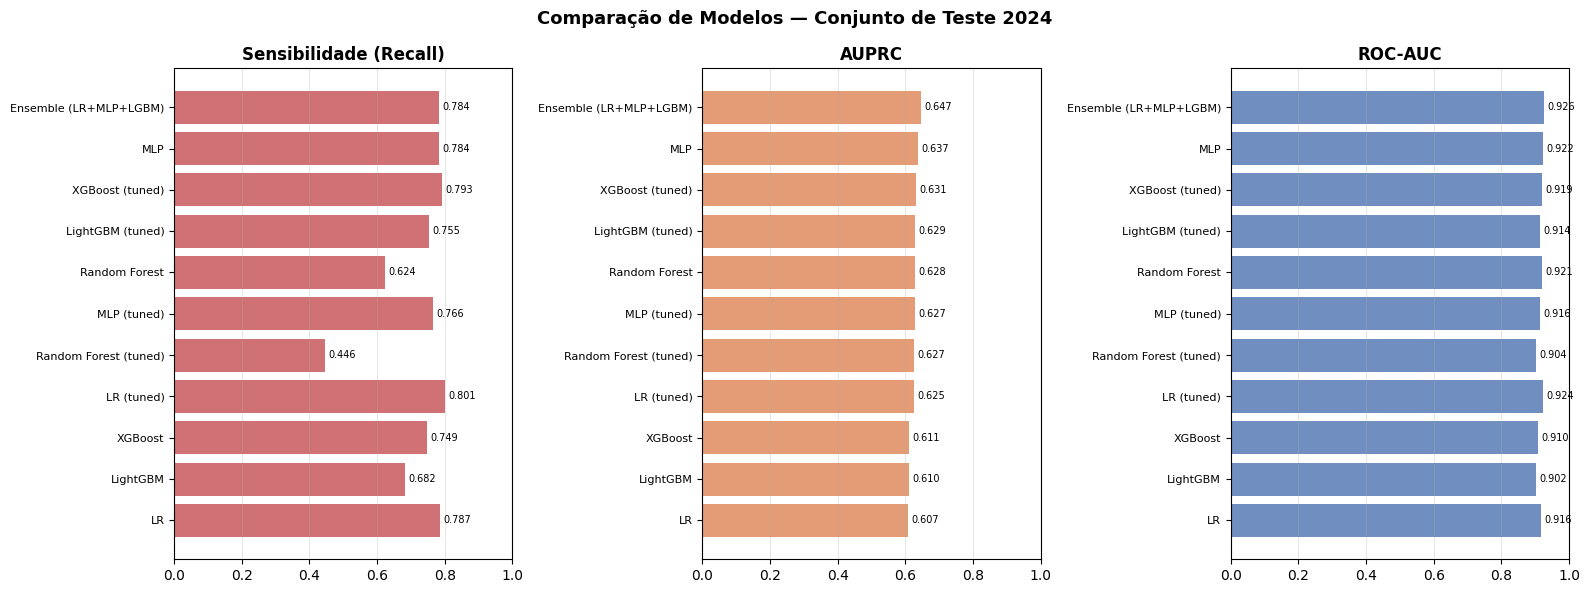

In [7]:
df_plot = df_comp.sort_values('auprc', ascending=True)
nomes   = df_plot['modelo'].tolist()
y_pos   = np.arange(len(nomes))

fig, axes = plt.subplots(1, 3, figsize=(16, max(6, len(nomes) * 0.45)))

metricas = [
    ('sensibilidade', '#C44E52', 'Sensibilidade (Recall)'),
    ('auprc',         '#DD8452', 'AUPRC'),
    ('roc_auc',       '#4C72B0', 'ROC-AUC'),
]

for ax, (col, cor, titulo) in zip(axes, metricas):
    vals = df_plot[col].tolist()
    bars = ax.barh(y_pos, vals, color=cor, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(nomes, fontsize=8)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=7)

plt.suptitle('Comparação de Modelos — Conjunto de Teste 2024', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'comparacao_barras.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Curvas ROC

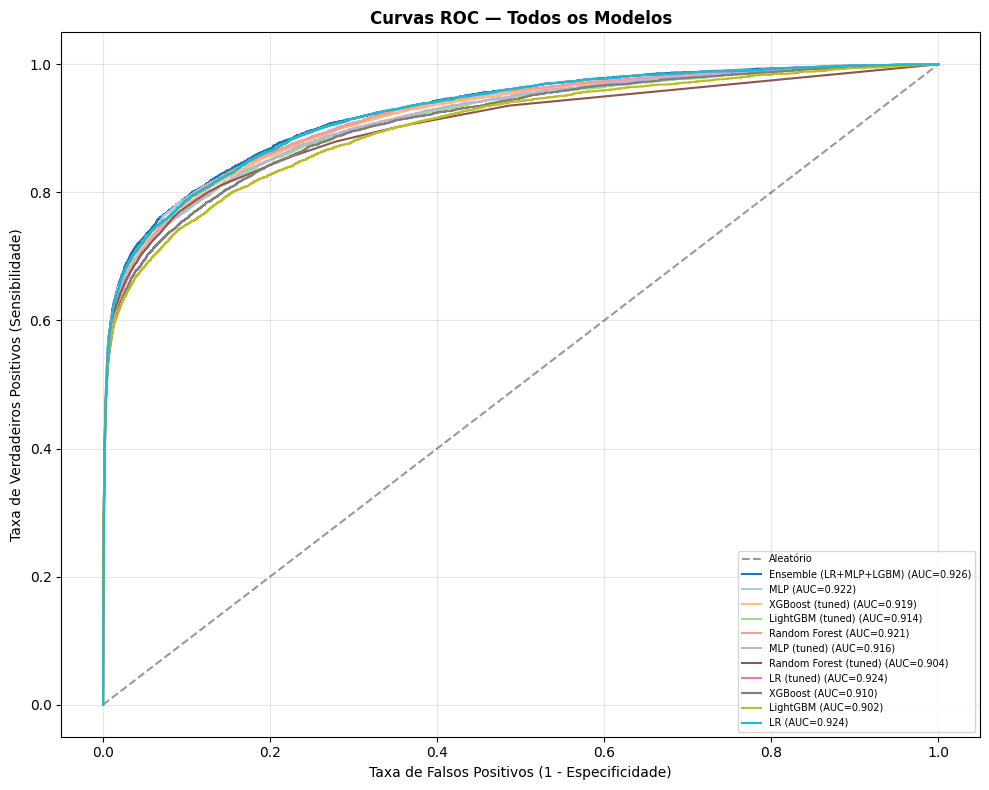

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatório')

cmap   = plt.get_cmap('tab20')
colors = [cmap(i / len(df_comp)) for i in range(len(df_comp))]

for i, row in df_comp.iterrows():
    pred_path = os.path.join(OUTPUT_MET, f"{row['arquivo']}_predicoes.parquet")
    if not os.path.exists(pred_path):
        continue
    preds = pd.read_parquet(pred_path)
    fpr, tpr, _ = roc_curve(preds['y_true'], preds['y_proba'])
    roc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i], lw=1.5,
            label=f"{row['modelo']} (AUC={roc:.3f})")

ax.set_xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
ax.set_title('Curvas ROC — Todos os Modelos', fontweight='bold')
ax.legend(loc='lower right', fontsize=7)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'comparacao_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Curvas Precision-Recall

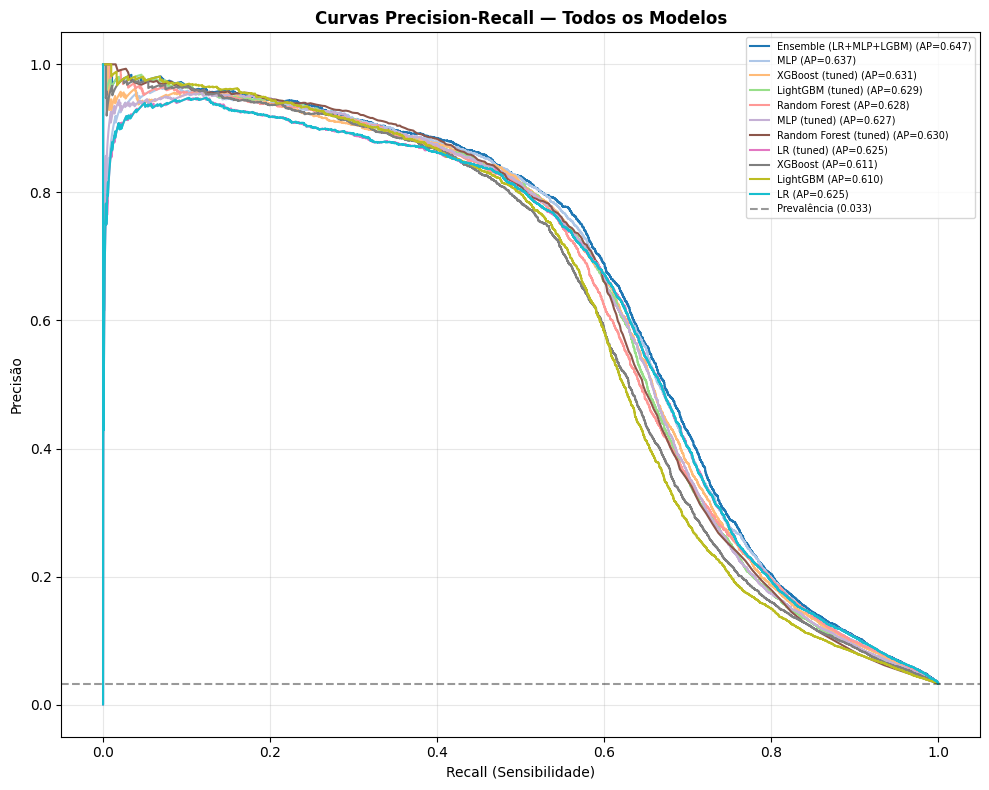

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

for i, row in df_comp.iterrows():
    pred_path = os.path.join(OUTPUT_MET, f"{row['arquivo']}_predicoes.parquet")
    if not os.path.exists(pred_path):
        continue
    preds = pd.read_parquet(pred_path)
    prec, rec, _ = precision_recall_curve(preds['y_true'], preds['y_proba'])
    ap = auc(rec, prec)
    ax.plot(rec, prec, color=colors[i], lw=1.5,
            label=f"{row['modelo']} (AP={ap:.3f})")

prevalencia = None
for i, row in df_comp.iterrows():
    pred_path = os.path.join(OUTPUT_MET, f"{row['arquivo']}_predicoes.parquet")
    if os.path.exists(pred_path):
        preds = pd.read_parquet(pred_path)
        prevalencia = preds['y_true'].mean()
        break
if prevalencia is not None:
    ax.axhline(prevalencia, color='k', linestyle='--', alpha=0.4,
               label=f'Prevalência ({prevalencia:.3f})')

ax.set_xlabel('Recall (Sensibilidade)')
ax.set_ylabel('Precisão')
ax.set_title('Curvas Precision-Recall — Todos os Modelos', fontweight='bold')
ax.legend(loc='upper right', fontsize=7)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PLT, 'comparacao_pr.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Análise por grupo — baseline vs tuned

In [10]:
# Agrupa por família de algoritmo para comparar baseline vs tuned
grupos = {
    'Logistic Regression': ['LR', 'LR (tuned)', 'LR + SMOTE 1:1', 'LR + SMOTE 1:5', 'LR + SMOTE 1:10'],
    'MLP':                 ['MLP', 'MLP (tuned)'],
    'LightGBM':            ['LightGBM', 'LightGBM (tuned)'],
    'XGBoost':             ['XGBoost', 'XGBoost (tuned)'],
    'Random Forest':       ['Random Forest', 'Random Forest (tuned)'],
    'Outros':              ['Naive Bayes', 'Ensemble (LR+MLP+LGBM)'],
}

print(f'{'Grupo':<22} {'Modelo':<28} {'Sensibilidade':>14} {'AUPRC':>8} {'ROC-AUC':>9}')
print('-' * 85)
for grupo, membros in grupos.items():
    subset = df_comp[df_comp['modelo'].isin(membros)]
    for _, r in subset.sort_values('auprc', ascending=False).iterrows():
        print(f'{grupo:<22} {r["modelo"]:<28} {r["sensibilidade"]:>14.4f} {r["auprc"]:>8.4f} {r["roc_auc"]:>9.4f}')
    print()

Grupo                  Modelo                        Sensibilidade    AUPRC   ROC-AUC
-------------------------------------------------------------------------------------
Logistic Regression    LR (tuned)                           0.8008   0.6250    0.9242
Logistic Regression    LR                                   0.7870   0.6067    0.9164

MLP                    MLP                                  0.7843   0.6369    0.9217
MLP                    MLP (tuned)                          0.7664   0.6272    0.9157

LightGBM               LightGBM (tuned)                     0.7549   0.6294    0.9136
LightGBM               LightGBM                             0.6820   0.6098    0.9024

XGBoost                XGBoost (tuned)                      0.7932   0.6314    0.9194
XGBoost                XGBoost                              0.7490   0.6112    0.9098

Random Forest          Random Forest                        0.6240   0.6276    0.9209
Random Forest          Random Forest (tuned)      

## 7. Melhor modelo e ranking final

In [11]:
# Ranking por prioridade: sensibilidade > auprc > roc_auc
df_rank = df_comp.copy()
df_rank['rank_sens']    = df_rank['sensibilidade'].rank(ascending=False)
df_rank['rank_auprc']   = df_rank['auprc'].rank(ascending=False)
df_rank['rank_roc']     = df_rank['roc_auc'].rank(ascending=False)
# Peso: sensibilidade=3, auprc=2, roc_auc=1
df_rank['score_ponder'] = (3 * df_rank['rank_sens'] + 2 * df_rank['rank_auprc'] + df_rank['rank_roc']) / 6
df_rank = df_rank.sort_values('score_ponder')

print('=== Ranking ponderado (sensibilidade×3 + AUPRC×2 + ROC-AUC×1) ===')
print()
for pos, (_, r) in enumerate(df_rank.iterrows(), 1):
    print(f'{pos:>2}. {r["modelo"]:<30} sens={r["sensibilidade"]:.4f}  auprc={r["auprc"]:.4f}  roc={r["roc_auc"]:.4f}')

melhor = df_rank.iloc[0]
print()
print(f'>>> Modelo recomendado: {melhor["modelo"]}')
print(f'    Sensibilidade: {melhor["sensibilidade"]:.4f}')
print(f'    AUPRC:         {melhor["auprc"]:.4f}')
print(f'    ROC-AUC:       {melhor["roc_auc"]:.4f}')

=== Ranking ponderado (sensibilidade×3 + AUPRC×2 + ROC-AUC×1) ===

 1. Ensemble (LR+MLP+LGBM)         sens=0.7843  auprc=0.6472  roc=0.9261
 2. XGBoost (tuned)                sens=0.7932  auprc=0.6314  roc=0.9194
 3. MLP                            sens=0.7843  auprc=0.6369  roc=0.9217
 4. LR (tuned)                     sens=0.8008  auprc=0.6250  roc=0.9242
 5. LightGBM (tuned)               sens=0.7549  auprc=0.6294  roc=0.9136
 6. MLP (tuned)                    sens=0.7664  auprc=0.6272  roc=0.9157
 7. LR                             sens=0.7870  auprc=0.6067  roc=0.9164
 8. Random Forest                  sens=0.6240  auprc=0.6276  roc=0.9209
 9. XGBoost                        sens=0.7490  auprc=0.6112  roc=0.9098
10. Random Forest (tuned)          sens=0.4457  auprc=0.6268  roc=0.9038
11. LightGBM                       sens=0.6820  auprc=0.6098  roc=0.9024

>>> Modelo recomendado: Ensemble (LR+MLP+LGBM)
    Sensibilidade: 0.7843
    AUPRC:         0.6472
    ROC-AUC:       0.9261


## 8. Salvamento

In [12]:
csv_path = os.path.join(OUTPUT_MET, 'COMPARACAO_TODOS_MODELOS.csv')
df_comp[cols_show].to_csv(csv_path, index=False)
print(f'Comparação salva: {csv_path}')

rank_path = os.path.join(OUTPUT_MET, 'RANKING_PONDERADO.csv')
df_rank[['modelo', 'sensibilidade', 'especificidade', 'auprc', 'roc_auc', 'f1', 'score_ponder']].to_csv(rank_path, index=False)
print(f'Ranking salvo:    {rank_path}')

Comparação salva: ../../output/metricas/COMPARACAO_TODOS_MODELOS.csv
Ranking salvo:    ../../output/metricas/RANKING_PONDERADO.csv
